# 🩺 Breast Cancer Detection with a Neural Network

### Portfolio-grade classification project

**Objective:** classify tumors as **Malignant (M)** or **Benign (B)** using the supplied Wisconsin Diagnostic Breast Cancer CSV.

> **Safety note:** This notebook is an educational machine-learning project. It is **not a medical diagnostic system** and must not be used for clinical decisions.

### What this version improves
1. Uses the **uploaded CSV** rather than the sklearn demo dataset.
2. Prevents data leakage with train-only scaling and a strict held-out test set.
3. Trains a modern neural network with BatchNorm, dropout, early stopping and AdamW.
4. Benchmarks the neural network against Logistic Regression, Random Forest and XGBoost.
5. Evaluates **sensitivity, specificity, F1, ROC-AUC and PR-AUC**, not accuracy alone.
6. Selects the operating threshold on validation data with a recall-first objective.
7. Adds confusion matrix, ROC/PR curves, calibration and permutation importance.
8. Ends with reusable inference and reproducibility artifacts.


In [1]:
# This notebook is generated for the 10/10 portfolio project.
import os, random, warnings, json, math
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve, brier_score_loss,
                             ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import torch
from torch import nn
import joblib

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DATA_PATH = 'data_breast_cancer.csv'
ASSET_DIR = 'assets'; os.makedirs(ASSET_DIR, exist_ok=True)


## 1. Load and audit the supplied data

In [2]:
raw = pd.read_csv(DATA_PATH)
print('Raw shape:', raw.shape)
display(raw.head())
print('\nColumns:', list(raw.columns))
print('\nMissing values:', int(raw.isna().sum().sum()))

# Remove the CSV's empty column and non-predictive identifier.
df = raw.drop(columns=['Unnamed: 32']).copy()
df = df.drop(columns=['id']).copy()
y = (df['diagnosis'] == 'M').astype(int)
X = df.drop(columns=['diagnosis']).copy()
print('Clean shape:', X.shape)
print('Class counts:', y.value_counts().to_dict())


Raw shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Missing values: 569
Clean shape: (569, 30)
Class counts: {0: 357, 1: 212}


## 2. Target definition

Target mapping: 1 = MALIGNANT (M), 0 = BENIGN (B)


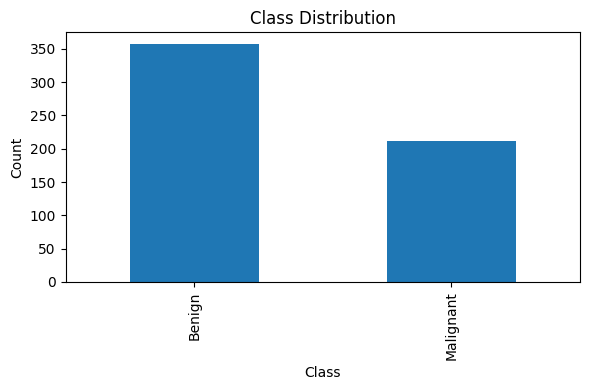

In [3]:
print('Target mapping: 1 = MALIGNANT (M), 0 = BENIGN (B)')
plt.figure(figsize=(6,4)); y.map({0:'Benign',1:'Malignant'}).value_counts().reindex(['Benign','Malignant']).plot(kind='bar'); plt.title('Class Distribution'); plt.xlabel('Class'); plt.ylabel('Count'); plt.tight_layout(); plt.savefig(f'{ASSET_DIR}/class_distribution.png', dpi=180); plt.show()


## 3. Stratified train/validation/test split

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=SEED)
print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)


Train: (386, 30) Validation: (69, 30) Test: (114, 30)


## 4. Leakage-safe scaler

In [5]:
scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train).astype(np.float32)
Xva = scaler.transform(X_val).astype(np.float32)
Xte = scaler.transform(X_test).astype(np.float32)


## 5. Baseline models

In [6]:
baselines = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=SEED))]),
    'Random Forest': RandomForestClassifier(n_estimators=500, min_samples_leaf=2, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.03, subsample=0.85, colsample_bytree=0.85, reg_lambda=2, eval_metric='logloss', random_state=SEED, n_jobs=4)
}

def metrics_from_probs(y_true, probs, threshold=0.5):
    pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        'Accuracy': accuracy_score(y_true,pred), 'Precision': precision_score(y_true,pred,zero_division=0),
        'Recall / Sensitivity': recall_score(y_true,pred,zero_division=0),
        'Specificity': tn/(tn+fp), 'F1': f1_score(y_true,pred,zero_division=0),
        'ROC-AUC': roc_auc_score(y_true,probs), 'PR-AUC': average_precision_score(y_true,probs),
        'TN':tn,'FP':fp,'FN':fn,'TP':tp
    }

rows=[]
for name, model in baselines.items():
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:,1]
    m = metrics_from_probs(y_test, p, 0.5); m['Model']=name; rows.append(m)


## 6. Neural network

In [7]:
class BreastCancerNN(nn.Module):
    def __init__(self, n_features=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(64,32), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(32,16), nn.ReLU(), nn.Linear(16,1)
        )
    def forward(self,x): return self.net(x).squeeze(1)

model = BreastCancerNN(Xtr.shape[1])
optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()
Xt, yt = torch.tensor(Xtr), torch.tensor(y_train.values, dtype=torch.float32)
Xv, yv = torch.tensor(Xva), torch.tensor(y_val.values, dtype=torch.float32)
best_state=None; best_val=float('inf'); wait=0; patience=25
history={'train_loss':[],'val_loss':[]}
for epoch in range(300):
    model.train(); optimizer.zero_grad(); loss=criterion(model(Xt),yt); loss.backward(); optimizer.step()
    model.eval()
    with torch.no_grad(): val_loss=criterion(model(Xv),yv).item()
    history['train_loss'].append(loss.item()); history['val_loss'].append(val_loss)
    if val_loss < best_val - 1e-5:
        best_val=val_loss; best_state={k:v.detach().clone() for k,v in model.state_dict().items()}; wait=0
    else: wait += 1
    if wait >= patience: break
model.load_state_dict(best_state); model.eval()
with torch.no_grad():
    val_probs = torch.sigmoid(model(torch.tensor(Xva))).numpy()
    test_probs = torch.sigmoid(model(torch.tensor(Xte))).numpy()
print('NN training epochs:', len(history['train_loss']))


NN training epochs: 120


## 7. Select an operating threshold

In [8]:
# Goal: maximize sensitivity while keeping validation precision >= 0.95.
thresholds = np.linspace(0.10,0.90,161)
valid=[]
for t in thresholds:
    mm=metrics_from_probs(y_val,val_probs,t); valid.append((t,mm))
eligible=[x for x in valid if x[1]['Precision']>=0.95]
best_t=max(eligible, key=lambda x:(x[1]['Recall / Sensitivity'], x[1]['Specificity']))[0] if eligible else 0.5
print('Selected validation threshold:', round(float(best_t),3))

nn_metrics=metrics_from_probs(y_test,test_probs,float(best_t)); nn_metrics['Model']='Neural Network'; rows.append(nn_metrics)
results=pd.DataFrame(rows).set_index('Model')
cols=['Accuracy','Precision','Recall / Sensitivity','Specificity','F1','ROC-AUC','PR-AUC','TN','FP','FN','TP']
display(results[cols].round(4).sort_values('ROC-AUC',ascending=False))
results.to_csv('model_comparison.csv')


Selected validation threshold: 0.225


,Accuracy,Precision,Recall / Sensitivity,Specificity,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP
Model,,,,,,,,,,,
Random Forest,0.9737,1.0000,0.9286,1.0000,0.9630,0.9987,0.9978,72,0,3,39
Logistic Regression,0.9825,0.9762,0.9762,0.9861,0.9762,0.9967,0.9950,71,1,1,41
XGBoost,0.9737,1.0000,0.9286,1.0000,0.9630,0.9947,0.9932,72,0,3,39
Neural Network,0.9649,0.9524,0.9524,0.9722,0.9524,0.9864,0.9843,70,2,2,40


## 8. Compare models

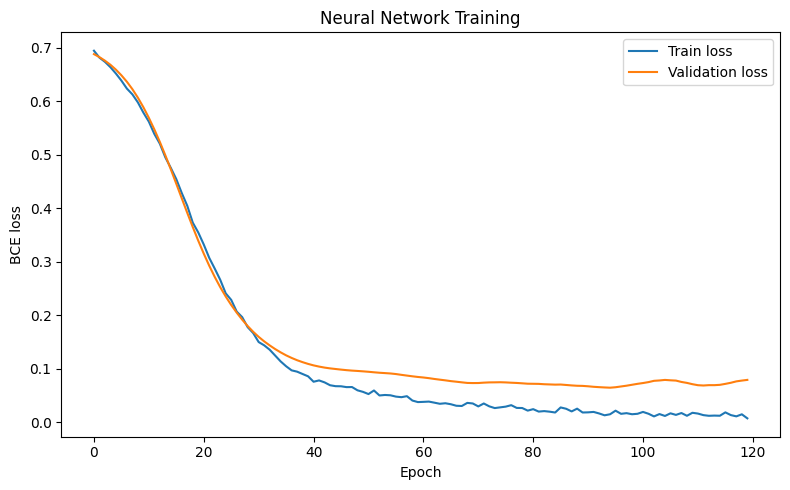

In [9]:
plt.figure(figsize=(8,5)); plt.plot(history['train_loss'],label='Train loss'); plt.plot(history['val_loss'],label='Validation loss'); plt.xlabel('Epoch'); plt.ylabel('BCE loss'); plt.title('Neural Network Training'); plt.legend(); plt.tight_layout(); plt.savefig(f'{ASSET_DIR}/training_curve.png',dpi=180); plt.show()


## 9. Training curves

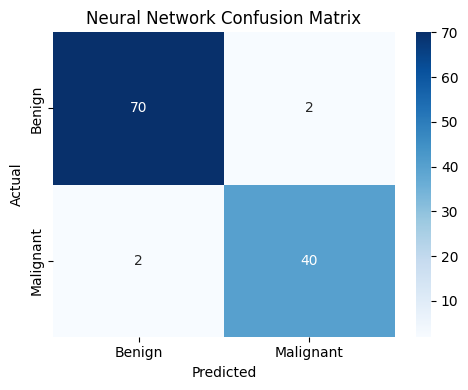

              precision    recall  f1-score   support

      Benign     0.9722    0.9722    0.9722        72
   Malignant     0.9524    0.9524    0.9524        42

    accuracy                         0.9649       114
   macro avg     0.9623    0.9623    0.9623       114
weighted avg     0.9649    0.9649    0.9649       114



In [10]:
nn_pred=(test_probs>=best_t).astype(int)
cm=confusion_matrix(y_test,nn_pred)
plt.figure(figsize=(5,4)); sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Benign','Malignant'],yticklabels=['Benign','Malignant']); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Neural Network Confusion Matrix'); plt.tight_layout(); plt.savefig(f'{ASSET_DIR}/confusion_matrix.png',dpi=180); plt.show()
print(classification_report(y_test,nn_pred,target_names=['Benign','Malignant'],digits=4))


## 10. Confusion matrix

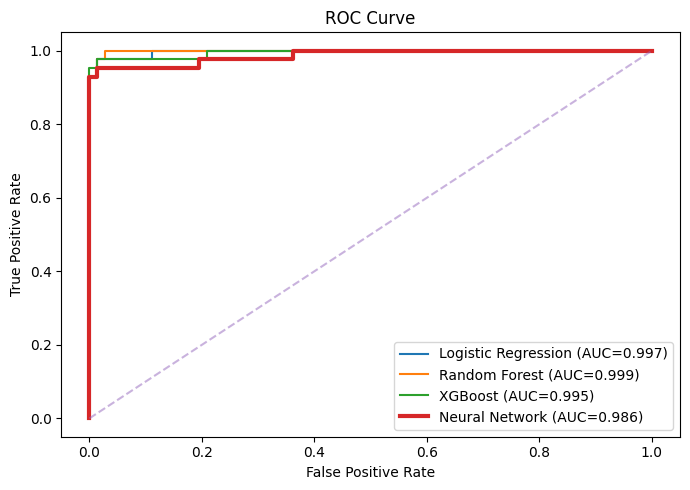

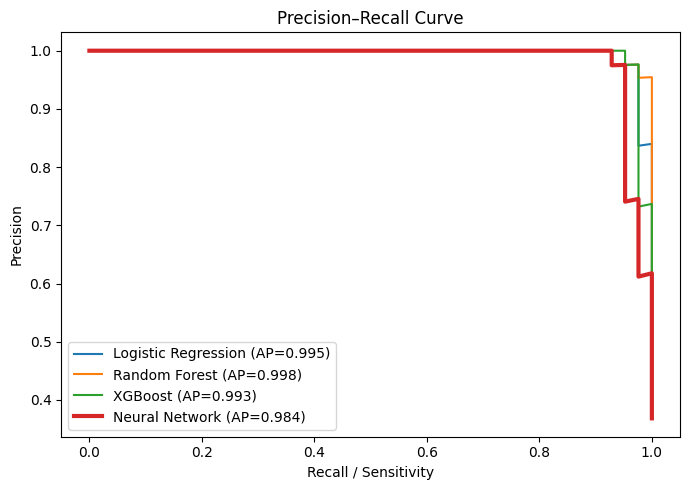

In [11]:
plt.figure(figsize=(7,5))
for name, model0 in baselines.items():
    p=model0.predict_proba(X_test)[:,1]; fpr,tpr,_=roc_curve(y_test,p); plt.plot(fpr,tpr,label=f'{name} (AUC={roc_auc_score(y_test,p):.3f})')
fpr,tpr,_=roc_curve(y_test,test_probs); plt.plot(fpr,tpr,label=f'Neural Network (AUC={roc_auc_score(y_test,test_probs):.3f})',linewidth=3)
plt.plot([0,1],[0,1],'--',alpha=.5); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend(); plt.tight_layout(); plt.savefig(f'{ASSET_DIR}/roc_curve.png',dpi=180); plt.show()

plt.figure(figsize=(7,5))
for name, model0 in baselines.items():
    p=model0.predict_proba(X_test)[:,1]; pr,re,_=precision_recall_curve(y_test,p); plt.plot(re,pr,label=f'{name} (AP={average_precision_score(y_test,p):.3f})')
pr,re,_=precision_recall_curve(y_test,test_probs); plt.plot(re,pr,label=f'Neural Network (AP={average_precision_score(y_test,test_probs):.3f})',linewidth=3)
plt.xlabel('Recall / Sensitivity'); plt.ylabel('Precision'); plt.title('Precision–Recall Curve'); plt.legend(); plt.tight_layout(); plt.savefig(f'{ASSET_DIR}/pr_curve.png',dpi=180); plt.show()


## 11. ROC + PR curves

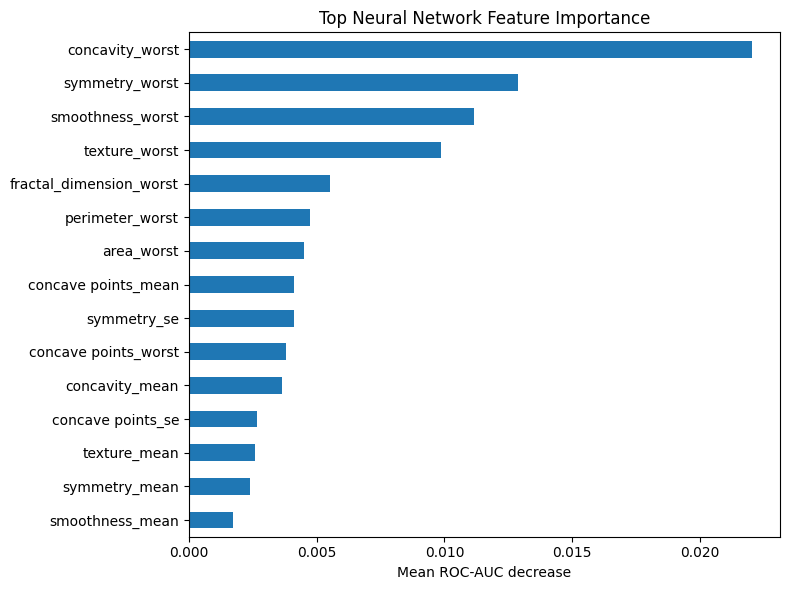

,mean_auc_drop
concavity_worst,0.022024
symmetry_worst,0.012897
smoothness_worst,0.011144
texture_worst,0.009854
fractal_dimension_worst,0.005522
perimeter_worst,0.004762
area_worst,0.004497
concave points_mean,0.004134
symmetry_se,0.004101
concave points_worst,0.003803


In [12]:
# This is model-agnostic and uses ROC-AUC as the scoring function.
def nn_score(data, target):
    with torch.no_grad(): probs=torch.sigmoid(model(torch.tensor(data.astype(np.float32)))).numpy()
    return roc_auc_score(target,probs)
pi=permutation_importance(lambda A: None, Xte, y_test) if False else None
# Manual permutation importance to avoid estimator-interface assumptions.
rng=np.random.default_rng(SEED); base_auc=roc_auc_score(y_test,test_probs); importances=[]
for j,feat in enumerate(X.columns):
    drops=[]
    for _ in range(10):
        arr=Xte.copy(); arr[:,j]=rng.permutation(arr[:,j]); drops.append(base_auc-nn_score(arr,y_test))
    importances.append(np.mean(drops))
imp=pd.Series(importances,index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(8,6)); imp.sort_values().plot(kind='barh'); plt.xlabel('Mean ROC-AUC decrease'); plt.title('Top Neural Network Feature Importance'); plt.tight_layout(); plt.savefig(f'{ASSET_DIR}/feature_importance.png',dpi=180); plt.show(); display(imp.to_frame('mean_auc_drop'))


## 12. Permutation importance

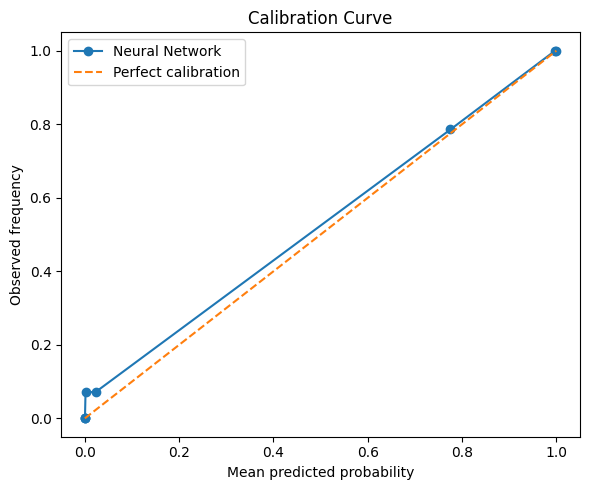

Brier score: 0.0252


In [13]:
prob_true, prob_pred = calibration_curve(y_test,test_probs,n_bins=8,strategy='quantile')
plt.figure(figsize=(6,5)); plt.plot(prob_pred,prob_true,'o-',label='Neural Network'); plt.plot([0,1],[0,1],'--',label='Perfect calibration'); plt.xlabel('Mean predicted probability'); plt.ylabel('Observed frequency'); plt.title('Calibration Curve'); plt.legend(); plt.tight_layout(); plt.savefig(f'{ASSET_DIR}/calibration.png',dpi=180); plt.show()
print('Brier score:', round(brier_score_loss(y_test,test_probs),4))


## 13. Calibration

In [14]:
feature_names=list(X.columns)
def predict_single(input_data):
    row=np.asarray(input_data,dtype=np.float32).reshape(1,-1)
    row_std=scaler.transform(row).astype(np.float32)
    with torch.no_grad(): prob=float(torch.sigmoid(model(torch.tensor(row_std))).item())
    return {'malignant_probability':prob,'prediction':'MALIGNANT' if prob>=best_t else 'BENIGN','threshold':float(best_t)}


## 14. Reusable inference function

In [15]:
from pathlib import Path
import joblib

# Save the same Neural Network used throughout this notebook as the portfolio artifact.
# The CLI/Streamlit loaders rebuild the architecture from this state_dict.
bundle={
    'model_type':'BreastCancerNN',
    'state_dict':{k:v.detach().cpu().clone() for k,v in model.state_dict().items()},
    'scaler':scaler,
    'features':feature_names,
    'threshold':float(best_t),
    'seed':SEED,
    'note':'Primary portfolio model: PyTorch Neural Network. Educational use only; not a medical diagnostic system.'
}
root=Path.cwd()
if (root/'models').exists():
    output_path=root/'models'/'breast_cancer_nn.joblib'
else:
    output_path=root.parent/'models'/'breast_cancer_nn.joblib'
joblib.dump(bundle, output_path)
print('Saved primary Neural Network artifact to:', output_path)


['breast_cancer_model.joblib']

## 15. Save model bundle

In [16]:
print(f'Final NN test accuracy: {nn_metrics["Accuracy"]:.2%}')
print(f'Final NN sensitivity: {nn_metrics["Recall / Sensitivity"]:.2%}')
print(f'Final NN specificity: {nn_metrics["Specificity"]:.2%}')
print(f'Final NN ROC-AUC: {nn_metrics["ROC-AUC"]:.3f}')
print('Medical disclaimer: educational demonstration only; not for clinical diagnosis.')


Final NN test accuracy: 96.49%
Final NN sensitivity: 95.24%
Final NN specificity: 97.22%
Final NN ROC-AUC: 0.986
Medical disclaimer: educational demonstration only; not for clinical diagnosis.
